In [ ]:
import os, sys, subprocess

CFG = dict(
    REPO            = "XYZAILab/XYZ-Aquila-SFT",
    LANG            = "en",
    N_STREAM        = 400,
    N_EVAL          = 40,
    MODEL_ID        = "Qwen/Qwen3-0.6B",
    MAX_SEQ_LEN     = 2048,
    LENGTH_POLICY   = "truncate",
    RUN_TRAINING    = True,
    MAX_STEPS       = 30,
    GRAD_ACCUM      = 8,
    LR              = 1e-4,
    LORA_R          = 16,
    RUN_EVAL        = True,
    N_EVAL_PROBES   = 24,
    OUT_DIR         = "/content/aquila_out",
    SEED            = 0,
)
os.makedirs(CFG["OUT_DIR"], exist_ok=True)

def pip(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-U", *pkgs], check=False)

pip("datasets>=3.0.0", "transformers>=4.51.0", "peft>=0.13.0", "accelerate>=1.0.0")

import json, re, math, random, statistics as stats
from collections import Counter, defaultdict
from dataclasses import dataclass, field
from typing import Any, Dict, List, Optional

import torch
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, get_cosine_schedule_with_warmup

random.seed(CFG["SEED"]); torch.manual_seed(CFG["SEED"])
DEV = "cuda" if torch.cuda.is_available() else "cpu"
BF16 = DEV == "cuda" and torch.cuda.is_bf16_supported()
print(f"device={DEV}  bf16={BF16}  torch={torch.__version__}")

print(f"\n[1] streaming {CFG['REPO']}:{CFG['LANG']} ...")
stream = load_dataset(CFG["REPO"], CFG["LANG"], split="train", streaming=True)
RAW: List[Dict[str, Any]] = list(stream.take(CFG["N_STREAM"]))
print(f"    pulled {len(RAW)} rows; keys = {list(RAW[0].keys())}")

_r = RAW[0]
print(f"    question[:110]        : {_r['question'][:110]}...")
print(f"    answer                : {_r['answer'][:80]}")
print(f"    number of tool calls  : {_r['number of tool calls']}")
print(f"    trajectory len        : {len(_r['trajectory'])} msgs")
print(f"    role sequence (first8): {[m['role'] for m in _r['trajectory'][:8]]}")

In [ ]:
TOOLS_BLOCK_RE = re.compile(r"<tools>\s*(.*?)\s*</tools>", re.S)
THINK_RE       = re.compile(r"<think>(.*?)</think>", re.S)
TOOL_RESP_RE   = re.compile(r"<tool_response>\s*(.*?)\s*</tool_response>", re.S)
TOOLS_HDR_RE   = re.compile(r"\n\n# Tools\n\n")

def iter_json_objects(text: str, limit: int = 1):
    """Nesting-safe JSON scanner. Regex like r'\\{.*?\\}' breaks on nested
    `arguments` objects, which every real tool call has."""
    dec, i, n, out = json.JSONDecoder(), 0, len(text), []
    while i < n and len(out) < limit:
        while i < n and text[i] not in "{[":
            i += 1
        if i >= n:
            break
        try:
            obj, end = dec.raw_decode(text, i)
        except json.JSONDecodeError:
            i += 1
            continue
        out.append(obj); i = end
    return out

def parse_tool_calls(content: str) -> List[Dict[str, Any]]:
    calls = []
    for m in re.finditer(r"<tool_call>", content):
        got = iter_json_objects(content[m.end():], limit=1)
        if got:
            calls.append(got[0])
    return calls

@dataclass
class Trajectory:
    question: str
    answer: str
    declared_calls: int
    messages: List[Dict[str, str]]
    system_core: str = ""
    tools: List[Dict[str, Any]] = field(default_factory=list)
    tools_suffix: str = ""
    calls: List[Dict[str, Any]] = field(default_factory=list)
    n_observations: int = 0
    n_think: int = 0

    @property
    def tool_names(self):  return [c.get("name", "?") for c in self.calls]
    @property
    def depth(self):       return len(self.messages)

def parse_row(row: Dict[str, Any]) -> Trajectory:
    msgs = [{"role": m["role"], "content": m["content"]} for m in row["trajectory"]]
    t = Trajectory(row["question"], row["answer"], row["number of tool calls"], msgs)

    if msgs and msgs[0]["role"] == "system":
        sysmsg = msgs[0]["content"]
        split = TOOLS_HDR_RE.search(sysmsg)
        if split:
            t.system_core   = sysmsg[:split.start()]
            t.tools_suffix  = sysmsg[split.start():]
        else:
            t.system_core = sysmsg
        blk = TOOLS_BLOCK_RE.search(sysmsg)
        if blk:
            t.tools = iter_json_objects(blk.group(1), limit=64)

    for m in msgs:
        if m["role"] == "assistant":
            t.calls += parse_tool_calls(m["content"])
            t.n_think += len(THINK_RE.findall(m["content"]))
        else:
            t.n_observations += len(TOOL_RESP_RE.findall(m["content"]))
    return t

TRAJ = [parse_row(r) for r in RAW]
t0 = TRAJ[0]
print(f"\n[2] parsed {len(TRAJ)} trajectories")
print(f"    tool schemas found : {[fn.get('function', fn).get('name') for fn in t0.tools]}")
print(f"    parsed calls       : {len(t0.calls)}  (declared {t0.declared_calls})")
print(f"    observations       : {t0.n_observations}   think blocks: {t0.n_think}")
if t0.calls:
    print(f"    sample call        : {json.dumps(t0.calls[0], ensure_ascii=False)[:200]}")

agree = sum(len(t.calls) == t.declared_calls for t in TRAJ)
print(f"    parser vs 'number of tool calls': {agree}/{len(TRAJ)} exact match")

calls_per   = [len(t.calls) for t in TRAJ]
depth_per   = [t.depth for t in TRAJ]
chars_per   = [sum(len(m["content"]) for m in t.messages) for t in TRAJ]
name_freq   = Counter(n for t in TRAJ for n in t.tool_names)
argkey_freq = defaultdict(Counter)
for t in TRAJ:
    for c in t.calls:
        args = c.get("arguments", {})
        if isinstance(args, dict):
            for k in args: argkey_freq[c.get("name", "?")][k] += 1

def q(xs, p):
    xs = sorted(xs); return xs[min(len(xs) - 1, int(p * len(xs)))]

print("\n[3] corpus statistics")
print(f"    tool calls / traj : mean {stats.mean(calls_per):.1f}  p50 {q(calls_per,.5)}  "
      f"p90 {q(calls_per,.9)}  max {max(calls_per)}")
print(f"    messages / traj   : mean {stats.mean(depth_per):.1f}  p90 {q(depth_per,.9)}  max {max(depth_per)}")
print(f"    chars / traj      : mean {stats.mean(chars_per):,.0f}  p90 {q(chars_per,.9):,}")
print(f"    tool distribution : {dict(name_freq)}")
for k, v in argkey_freq.items():
    print(f"      {k:<24} arg keys -> {dict(v.most_common(6))}")

tot = sum(chars_per); top = sum(sorted(chars_per)[-max(1, len(chars_per)//10):])
print(f"    top-10% longest trajectories hold {100*top/tot:.1f}% of all characters")

fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
ax[0].hist(calls_per, bins=40); ax[0].set_yscale("log"); ax[0].set_title("tool calls / trajectory")
ax[1].hist(depth_per, bins=40); ax[1].set_yscale("log"); ax[1].set_title("messages / trajectory")
ax[2].bar(list(name_freq), list(name_freq.values())); ax[2].set_title("tool usage"); ax[2].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

In [ ]:
QWEN3_TOOLS_TMPL = (
    "\n\n# Tools\n\nYou may call one or more functions to assist with the user query.\n\n"
    "You are provided with function signatures within <tools></tools> XML tags:\n<tools>\n"
    "{lines}\n</tools>\n\nFor each function call, return a json object with function name "
    "and arguments within <tool_call></tool_call> XML tags:\n<tool_call>\n"
    '{{"name": <function-name>, "arguments": <args-json-object>}}\n</tool_call>'
)

def extract_tools(t: Trajectory) -> Dict[str, Any]:
    """message-embedded schemas -> {'messages': [...], 'tools': [...]}"""
    msgs = [dict(m) for m in t.messages]
    if msgs and msgs[0]["role"] == "system":
        msgs[0]["content"] = t.system_core
    return {"messages": msgs, "tools": t.tools,
            "question": t.question, "answer": t.answer}

def render_tools(rec: Dict[str, Any]) -> List[Dict[str, str]]:
    """inverse: structured tools -> schemas re-embedded in the system message"""
    msgs = [dict(m) for m in rec["messages"]]
    if rec["tools"] and msgs and msgs[0]["role"] == "system":
        lines = "\n".join(json.dumps(x, ensure_ascii=False) for x in rec["tools"])
        msgs[0]["content"] = msgs[0]["content"] + QWEN3_TOOLS_TMPL.format(lines=lines)
    return msgs

_rt = render_tools(extract_tools(t0))
exact = _rt[0]["content"] == t0.messages[0]["content"]
print(f"\n[4] extract->render byte-exact: {exact}")
if not exact:
    print("    template drift detected -> using verbatim tools_suffix for render()")
    a, b = t0.messages[0]["content"], _rt[0]["content"]
    i = next((i for i in range(min(len(a), len(b))) if a[i] != b[i]), min(len(a), len(b)))
    print(f"    first divergence @{i}: {a[i:i+70]!r}  vs  {b[i:i+70]!r}")

tok = AutoTokenizer.from_pretrained(CFG["MODEL_ID"])
if tok.pad_token is None:
    tok.pad_token = tok.eos_token

IM_START, IM_END, NL = "<|im_start|>", "<|im_end|>", "\n"

def render_and_mask(t: Trajectory, max_len: int, policy: str):
    """Manual ChatML so we control masking token-exactly.

    WHY NOT apply_chat_template(): Qwen3's template deletes <think>...</think>
    from every assistant turn except the last. On this dataset that silently
    destroys most of the reasoning supervision you are paying to train on.
    """
    ids, labels = [], []
    for m in t.messages:
        head = tok(f"{IM_START}{m['role']}{NL}", add_special_tokens=False).input_ids
        body = tok(m["content"], add_special_tokens=False).input_ids
        tail = tok(f"{IM_END}{NL}", add_special_tokens=False).input_ids
        seg  = head + body + tail
        if m["role"] == "assistant":
            lab = [-100] * len(head) + body + tail
        else:
            lab = [-100] * len(seg)
        ids += seg; labels += lab

    if len(ids) > max_len:
        if policy == "drop":
            return None
        ids, labels = ids[:max_len], labels[:max_len]
    if all(l == -100 for l in labels):
        return None
    return {"input_ids": ids, "labels": labels}

_probe = [{"role": "system", "content": "S"}, {"role": "user", "content": "U"},
          {"role": "assistant", "content": "A"}]
_mine = "".join(f"{IM_START}{m['role']}{NL}{m['content']}{IM_END}{NL}" for m in _probe)
_theirs = tok.apply_chat_template(_probe, tokenize=False, add_generation_prompt=False)
print(f"\n[5] manual ChatML == chat_template on tool-free probe: {_mine == _theirs}")
if _mine != _theirs:
    print(f"    mine  : {_mine!r}\n    theirs: {_theirs!r}  (informational only)")

ENC = [e for e in (render_and_mask(t, CFG["MAX_SEQ_LEN"], CFG["LENGTH_POLICY"]) for t in TRAJ) if e]
sup = [sum(1 for x in e["labels"] if x != -100) / len(e["labels"]) for e in ENC]
print(f"    encoded {len(ENC)}/{len(TRAJ)} examples")
print(f"    supervised-token ratio: mean {stats.mean(sup):.3f}  p10 {q(sup,.1):.3f}  p90 {q(sup,.9):.3f}")
over = sum(1 for t in TRAJ if sum(len(tok(m['content'], add_special_tokens=False).input_ids)
                                  for m in t.messages[:3]) > CFG["MAX_SEQ_LEN"])
print(f"    trajectories whose first 3 msgs alone exceed MAX_SEQ_LEN: {over}")

SPLIT = len(ENC) - min(CFG["N_EVAL"], len(ENC)//5)
TRAIN_ENC, EVAL_TRAJ = ENC[:SPLIT], TRAJ[SPLIT:]

class SFTSet(torch.utils.data.Dataset):
    def __init__(self, rows): self.rows = rows
    def __len__(self):        return len(self.rows)
    def __getitem__(self, i): return self.rows[i]

def collate(batch):
    L = max(len(b["input_ids"]) for b in batch)
    pad = tok.pad_token_id
    return {
        "input_ids":      torch.tensor([b["input_ids"] + [pad]*(L-len(b["input_ids"])) for b in batch]),
        "labels":         torch.tensor([b["labels"]    + [-100]*(L-len(b["labels"]))   for b in batch]),
        "attention_mask": torch.tensor([[1]*len(b["input_ids"]) + [0]*(L-len(b["input_ids"])) for b in batch]),
    }

loader = torch.utils.data.DataLoader(SFTSet(TRAIN_ENC), batch_size=1, shuffle=True, collate_fn=collate)
print(f"\n[6] train={len(TRAIN_ENC)}  eval_trajectories={len(EVAL_TRAJ)}")

In [ ]:
def build_probes(trajs, n):
    """Teacher-forced probes: cut the trajectory right before an assistant turn
    that issues a tool call; the gold label is that call."""
    probes = []
    for t in trajs:
        for i, m in enumerate(t.messages):
            if m["role"] != "assistant":
                continue
            gold = parse_tool_calls(m["content"])
            if not gold:
                continue
            prefix = "".join(f"{IM_START}x['role']{NL}" for x in [])
            prefix = "".join(f"{IM_START}{p['role']}{NL}{p['content']}{IM_END}{NL}"
                             for p in t.messages[:i]) + f"{IM_START}assistant{NL}"
            if len(tok(prefix, add_special_tokens=False).input_ids) > CFG["MAX_SEQ_LEN"] - 160:
                continue
            probes.append({"prefix": prefix, "gold": gold[0]})
            break
        if len(probes) >= n:
            break
    return probes

@torch.no_grad()
def eval_tool_calls(model, probes, tag):
    model.eval()
    name_hit = arg_f1 = parsed = 0
    for p in probes:
        enc = tok(p["prefix"], return_tensors="pt", add_special_tokens=False).to(model.device)
        out = model.generate(**enc, max_new_tokens=160, do_sample=False,
                             pad_token_id=tok.pad_token_id)
        gen = tok.decode(out[0][enc.input_ids.shape[1]:], skip_special_tokens=True)
        pred = (parse_tool_calls(gen) or iter_json_objects(gen, limit=1) or [None])[0]
        if not isinstance(pred, dict):
            continue
        parsed += 1
        g = p["gold"]
        name_hit += int(pred.get("name") == g.get("name"))
        pk = set((pred.get("arguments") or {}).keys()) if isinstance(pred.get("arguments"), dict) else set()
        gk = set((g.get("arguments") or {}).keys())    if isinstance(g.get("arguments"), dict) else set()
        if pk or gk:
            inter = len(pk & gk)
            arg_f1 += 0.0 if inter == 0 else 2*inter/(len(pk)+len(gk))
    n = max(1, len(probes))
    print(f"    [{tag}] parseable {parsed}/{n} | tool-name acc {name_hit/n:.3f} | arg-key F1 {arg_f1/n:.3f}")
    return dict(parsed=parsed/n, name_acc=name_hit/n, arg_f1=arg_f1/n)

PROBES = build_probes(EVAL_TRAJ, CFG["N_EVAL_PROBES"])
print(f"    built {len(PROBES)} teacher-forced probes")

results = {}
if CFG["RUN_TRAINING"]:
    from peft import LoraConfig, get_peft_model

    dtype = torch.bfloat16 if BF16 else torch.float32
    model = AutoModelForCausalLM.from_pretrained(
        CFG["MODEL_ID"], torch_dtype=dtype, attn_implementation="sdpa").to(DEV)
    model.config.use_cache = False
    model.gradient_checkpointing_enable()
    model.enable_input_require_grads()

    if CFG["RUN_EVAL"] and PROBES and DEV == "cuda":
        print("\n[8] baseline eval")
        results["before"] = eval_tool_calls(model, PROBES, "base")

    model = get_peft_model(model, LoraConfig(
        r=CFG["LORA_R"], lora_alpha=2*CFG["LORA_R"], lora_dropout=0.05,
        bias="none", task_type="CAUSAL_LM",
        target_modules=["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"]))
    model.print_trainable_parameters()

    opt   = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad],
                              lr=CFG["LR"], weight_decay=0.0, betas=(0.9, 0.95))
    sched = get_cosine_schedule_with_warmup(opt, 5, CFG["MAX_STEPS"])
    scaler = torch.amp.GradScaler("cuda", enabled=(DEV == "cuda" and not BF16))
    amp_dt = torch.bfloat16 if BF16 else torch.float16

    print(f"\n[7] training {CFG['MAX_STEPS']} steps "
          f"(bs1 x accum{CFG['GRAD_ACCUM']} = {CFG['GRAD_ACCUM']} traj/step)")
    model.train(); step = 0; run = None; it = iter(loader)
    while step < CFG["MAX_STEPS"]:
        opt.zero_grad(set_to_none=True); acc = 0.0
        for _ in range(CFG["GRAD_ACCUM"]):
            try:    batch = next(it)
            except StopIteration:
                it = iter(loader); batch = next(it)
            batch = {k: v.to(DEV) for k, v in batch.items()}
            with torch.autocast(DEV, dtype=amp_dt, enabled=(DEV == "cuda")):
                loss = model(**batch).loss / CFG["GRAD_ACCUM"]
            scaler.scale(loss).backward() if scaler.is_enabled() else loss.backward()
            acc += loss.item()
        if scaler.is_enabled():
            scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad], 1.0)
        (scaler.step(opt), scaler.update()) if scaler.is_enabled() else opt.step()
        sched.step(); step += 1
        run = acc if run is None else 0.9*run + 0.1*acc
        if step % 5 == 0 or step == 1:
            print(f"    step {step:>3}/{CFG['MAX_STEPS']}  loss {acc:.4f}  ema {run:.4f}  "
                  f"lr {sched.get_last_lr()[0]:.2e}  ppl {math.exp(min(20, acc)):.1f}")

    model.save_pretrained(f"{CFG['OUT_DIR']}/lora_adapter"); tok.save_pretrained(f"{CFG['OUT_DIR']}/lora_adapter")
    print(f"    adapter -> {CFG['OUT_DIR']}/lora_adapter")

    if CFG["RUN_EVAL"] and PROBES and DEV == "cuda":
        print("\n[8] post-training eval")
        model.config.use_cache = True
        results["after"] = eval_tool_calls(model, PROBES, "lora")
        model.config.use_cache = False

    if "before" in results and "after" in results:
        print("\n    delta:", {k: round(results['after'][k] - results['before'][k], 3)
                               for k in results['after']})
        print("    (30 steps on ~350 trajectories is a smoke test, not a result — "
              "expect noise, and scale N_STREAM/MAX_STEPS for anything real.)")

device=cuda  bf16=True  torch=2.11.0+cu128

[1] streaming XYZAILab/XYZ-Aquila-SFT:en ...


README.md:   0%|          | 0.00/7.94k [00:00<?, ?B/s]

    pulled 400 rows; keys = ['question', 'answer', 'number of tool calls', 'trajectory']
    question[:110]        : Identify the individual satisfying all constraints: An advocate for international peace, recognized with the s...
    answer                : Carl von Ossietzky
    number of tool calls  : 9
    trajectory len        : 21 msgs
    role sequence (first8): ['system', 'user', 'assistant', 'user', 'assistant', 'user', 'assistant', 'user']

[2] parsed 400 trajectories
    tool schemas found : []
    parsed calls       : 9  (declared 9)
    observations       : 9   think blocks: 10
    sample call        : {"name": "web_search", "arguments": {"query": "university renamed 1990s after Nobel Peace Prize laureate northern Europe", "num": 10}}
    parser vs 'number of tool calls': 400/400 exact match

[3] corpus statistics
    tool calls / traj : mean 84.7  p50 71  p90 176  max 287
    messages / traj   : mean 172.3  p90 355  max 577
    chars / traj      : mean 419,221  p90 827,34

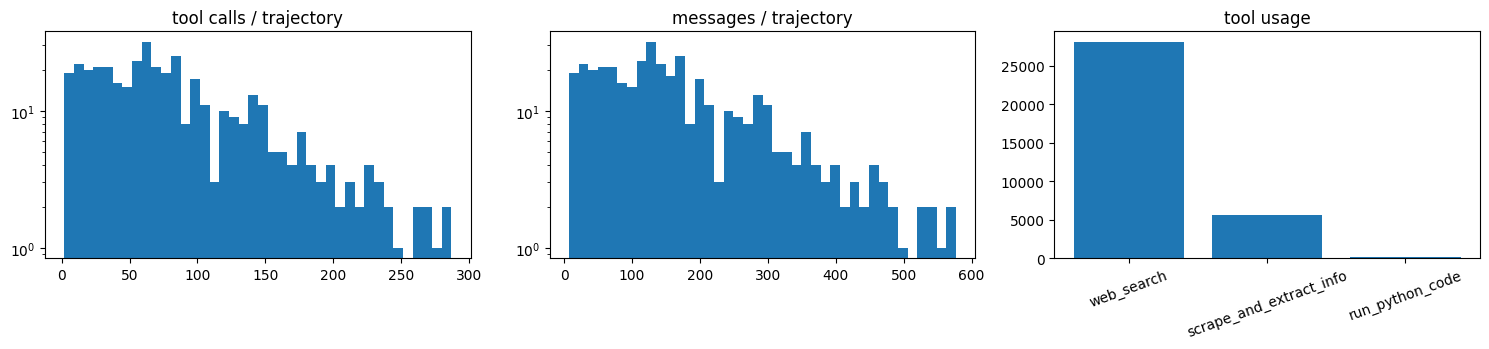


[4] extract->render byte-exact: False
    template drift detected -> using verbatim tools_suffix for render()
    first divergence @1225: '\n\n# Tools\n\nYou may call one or more functions to assist with the user '  vs  ''


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.73k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.50GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]


[8] baseline eval


In [ ]:
struct_path = f"{CFG['OUT_DIR']}/aquila_{CFG['LANG']}_structured_tools.jsonl"
with open(struct_path, "w", encoding="utf-8") as f:
    for t in TRAJ:
        f.write(json.dumps(extract_tools(t), ensure_ascii=False) + "\n")

stats_path = f"{CFG['OUT_DIR']}/corpus_stats.json"
with open(stats_path, "w") as f:
    json.dump({"n": len(TRAJ), "tool_freq": dict(name_freq),
               "calls_mean": stats.mean(calls_per), "calls_max": max(calls_per),
               "depth_p90": q(depth_per, .9), "encoded": len(ENC),
               "supervised_ratio_mean": stats.mean(sup), "eval": results}, f, indent=2)

print(f"\n[9] wrote:\n    {struct_path}\n    {stats_path}")
print("done.")